# Exploring Collinearity

We build a random dataset, then deliberately make columns linearly dependent and watch what happens to the correlation matrix.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
cols = [f"c{i}" for i in range(10)]

def heatmap(df, title):
    plt.figure(figsize=(7, 6))
    sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f", annot_kws={"size": 7})
    plt.title(title)
    plt.show()

## 1. A random 100×10 matrix
Every column is independent noise, so correlations should be near 0 off the diagonal.

In [2]:
X = rng.normal(size=(100, 10))
df = pd.DataFrame(X, columns=cols)
df.head()

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-0.016801,-0.853044
1,0.879398,0.777792,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926
2,-0.184862,-0.680930,1.222541,-0.154529,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821
3,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593
4,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,0.067579


## 2. Correlation heatmap

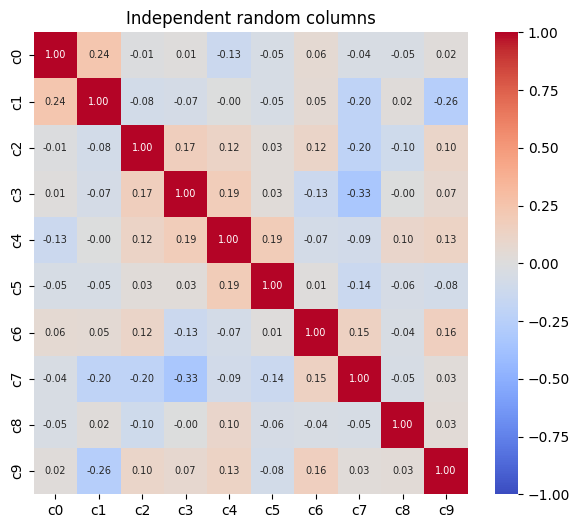

In [3]:
heatmap(df, "Independent random columns")

## 3. One column a multiple of another: c = k·c′
Set `c7 = 3 * c2`. The correlation between them becomes exactly 1.

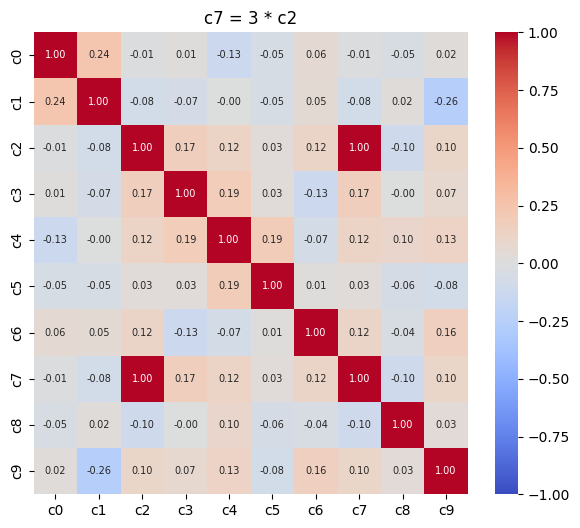

In [4]:
k = 3
df2 = df.copy()
df2["c7"] = k * df2["c2"]
heatmap(df2, "c7 = 3 * c2")

## 4. One column a combination of two others: c = k′·c′ + k″·c″
Set `c7 = 2*c2 - 1.5*c5`. No single pair is perfectly correlated, but the column is still perfectly predictable from the other two.

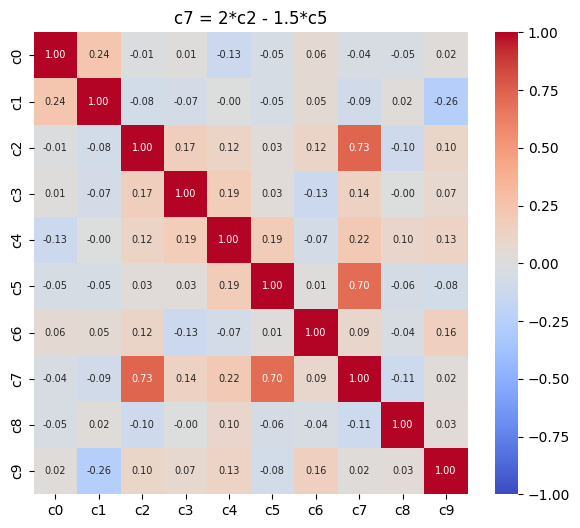

In [5]:
k1, k2 = 2, 2
df3 = df.copy()
df3["c7"] = k1 * df3["c2"] + k2 * df3["c5"]
heatmap(df3, "c7 = 2*c2 - 1.5*c5")

## 5. What the heatmap hides
The pairwise correlations with `c7` are only moderate, yet the matrix is rank-deficient. Compare rank and condition number.

In [6]:
for name, d in [("independent", df), ("c7 = 3*c2", df2), ("c7 = 2*c2 - 1.5*c5", df3)]:
    print(f"{name:20s} rank={np.linalg.matrix_rank(d.values)}  cond={np.linalg.cond(d.values):.3g}")

independent          rank=10  cond=2.1
c7 = 3*c2            rank=9  cond=2.59e+16
c7 = 2*c2 - 1.5*c5   rank=9  cond=8.79e+15


## 6. Realistic collinearity: add noise to the combination
Real dependent features are rarely exact. Now `c7 = 2*c2 - 1.5*c5 + ε` with ε ~ N(0, σ²).

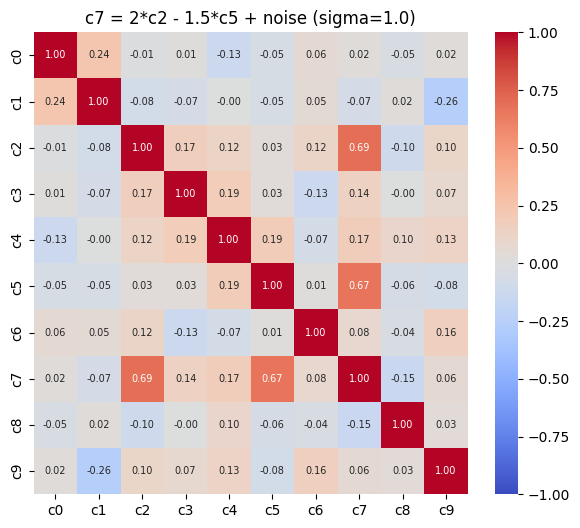

In [7]:
sigma = 1.0
df4 = df.copy()
df4["c7"] = k1 * df4["c2"] + k2 * df4["c5"] + rng.normal(scale=sigma, size=len(df4))
heatmap(df4, f"c7 = 2*c2 - 1.5*c5 + noise (sigma={sigma})")

## 7. Rank vs. condition number with noise
The noise makes the matrix technically full rank again, so `matrix_rank` no longer flags the problem. The condition number is the better signal, and it grows as the noise shrinks.

In [8]:
print(f"{'sigma':>8s} {'rank':>5s} {'cond':>10s} {'R^2 of c7 on c2,c5':>20s}")
for s in [0, 0.01, 0.1, 0.5, 1.0, 3.0]:
    d = df.copy()
    d["c7"] = k1 * d["c2"] + k2 * d["c5"] + rng.normal(scale=s, size=len(d))
    A = d[["c2", "c5"]].values
    coef, *_ = np.linalg.lstsq(A, d["c7"].values, rcond=None)
    resid = d["c7"].values - A @ coef
    r2 = 1 - resid.var() / d["c7"].var()
    print(f"{s:8.2f} {np.linalg.matrix_rank(d.values):5d} {np.linalg.cond(d.values):10.3g} {r2:20.4f}")

   sigma  rank       cond   R^2 of c7 on c2,c5
    0.00     9   8.79e+15               1.0000
    0.01    10        882               1.0000
    0.10    10       83.1               0.9985
    0.50    10       18.7               0.9653
    1.00    10       9.42               0.8800
    3.00    10       7.15               0.4834


Even at moderate noise the condition number is well above the independent baseline (~2), and `c7` is still almost fully explained by `c2` and `c5`, even though its pairwise correlations with each look unremarkable.

## 8. Regression coefficients under collinearity
Create a target `y` that is a linear function of all ten columns plus noise, using fixed true weights. We build two feature sets: the independent one, and a collinear one where `c7` is a noisy combination of `c2` and `c5`. Then fit 20 linear regressions, each on a different random train/test split, and compare how much each coefficient moves.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

true_w = rng.uniform(1, 3, size=10)          # same true weights for both datasets
sigma_c = 0.3                             # noise in the collinear relationship

X_ind = df.copy()
X_col = df.copy()
X_col["c7"] = k1 * X_col["c2"] + k2 * X_col["c5"] + rng.normal(scale=sigma_c, size=len(X_col))

noise_y = rng.normal(scale=1.0, size=len(df))
y_ind = X_ind.values @ true_w + noise_y
y_col = X_col.values @ true_w + noise_y

def many_fits(X, y, n=20):
    coefs = []
    for seed in range(n):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed)
        coefs.append(LinearRegression().fit(Xtr, ytr).coef_)
    return pd.DataFrame(coefs, columns=cols)

coef_ind = many_fits(X_ind, y_ind)
coef_col = many_fits(X_col, y_col)

summary = pd.DataFrame({
    "true": true_w,
    "ind mean": coef_ind.mean().values, "ind std": coef_ind.std().values,
    "col mean": coef_col.mean().values, "col std": coef_col.std().values,
}, index=cols).round(3)
summary

,true,ind mean,ind std,col mean,col std
c0,2.917,2.843,0.067,2.844,0.067
c1,2.420,2.118,0.078,2.112,0.077
c2,2.271,2.224,0.081,2.423,0.441
c3,2.488,2.523,0.054,2.514,0.055
c4,2.063,2.180,0.075,2.180,0.075
c5,1.952,1.904,0.059,2.097,0.406
c6,1.899,2.129,0.087,2.131,0.088
c7,2.281,2.314,0.066,2.181,0.212
c8,1.403,1.419,0.066,1.421,0.072
c9,2.776,2.701,0.037,2.701,0.036


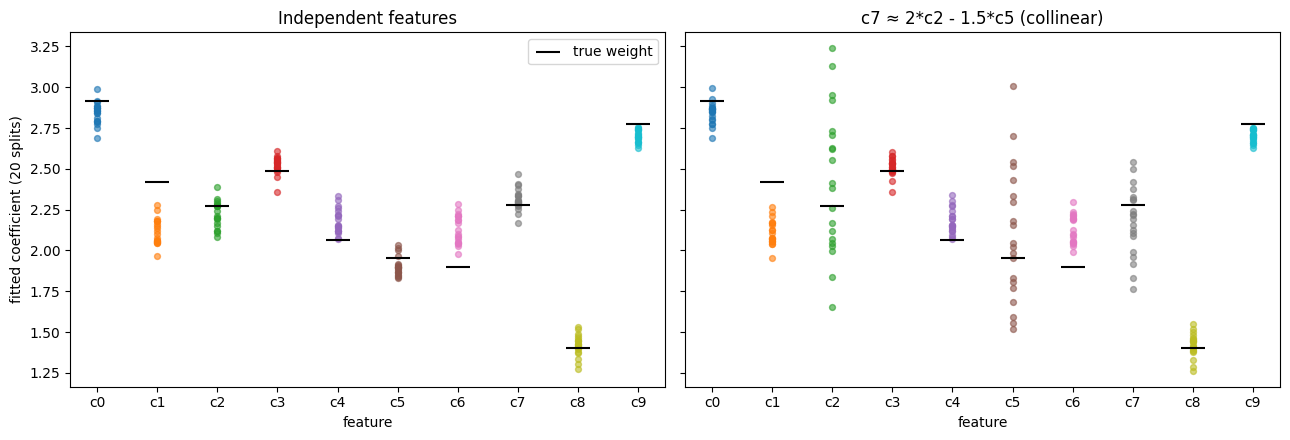

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, coefs, title in [(axes[0], coef_ind, "Independent features"),
                         (axes[1], coef_col, "c7 ≈ 2*c2 - 1.5*c5 (collinear)")]:
    for i, c in enumerate(cols):
        ax.scatter([i] * len(coefs), coefs[c], alpha=0.6, s=18)
    ax.scatter(range(10), true_w, marker="_", s=300, color="k", label="true weight")
    ax.set_xticks(range(10)); ax.set_xticklabels(cols)
    ax.set_title(title); ax.set_xlabel("feature")
axes[0].set_ylabel("fitted coefficient (20 splits)")
axes[0].legend()
plt.tight_layout(); plt.show()

With independent features the 20 fits agree closely with each other and with the true weights. With the collinear set, the coefficients of `c2`, `c5` and `c7` swing widely from split to split (and can offset each other, e.g. `c2` too high while `c7` too low), even though the other columns stay stable. The model's predictions can remain good while the individual coefficients become unreliable, so they can't be interpreted as each feature's effect.

## 9. Statsmodels report and confidence intervals
Fit OLS with statsmodels on a single train/test split, for both the independent and the collinear feature sets. The summary reports standard errors and 95% confidence intervals for each coefficient.

In [11]:
import statsmodels.api as sm

def sm_fit(X, y, seed=0):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed)
    return sm.OLS(ytr, sm.add_constant(Xtr)).fit()

res_ind = sm_fit(X_ind, y_ind)
print("INDEPENDENT FEATURES")
print(res_ind.summary())

INDEPENDENT FEATURES
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     364.3
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           3.83e-49
Time:                        11:00:51   Log-Likelihood:                -90.533
No. Observations:                  70   AIC:                             203.1
Df Residuals:                      59   BIC:                             227.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2040      0.12

In [12]:
res_col = sm_fit(X_col, y_col)
print("COLLINEAR FEATURES (c7 ≈ 2*c2 - 1.5*c5)")
print(res_col.summary())

COLLINEAR FEATURES (c7 ≈ 2*c2 - 1.5*c5)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     1043.
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.79e-62
Time:                        11:00:51   Log-Likelihood:                -90.464
No. Observations:                  70   AIC:                             202.9
Df Residuals:                      59   BIC:                             227.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

In [13]:
ci = pd.DataFrame({
    "true": true_w,
    "ind coef": res_ind.params[cols].values,
    "ind CI width": (res_ind.conf_int()[1] - res_ind.conf_int()[0])[cols].values,
    "col coef": res_col.params[cols].values,
    "col CI width": (res_col.conf_int()[1] - res_col.conf_int()[0])[cols].values,
    "col CI covers true": ((res_col.conf_int()[0][cols] <= true_w) & (true_w <= res_col.conf_int()[1][cols])).values,
}, index=cols).round(3)
ci

,true,ind coef,ind CI width,col coef,col CI width,col CI covers true
c0,2.917,2.856,0.477,2.852,0.476,True
c1,2.420,2.067,0.620,2.079,0.578,False
c2,2.271,2.301,0.501,2.627,3.292,True
c3,2.488,2.482,0.508,2.483,0.475,True
c4,2.063,2.156,0.549,2.155,0.547,True
c5,1.952,1.869,0.527,2.180,3.153,True
c6,1.899,2.247,0.468,2.237,0.457,False
c7,2.281,2.252,0.612,2.125,1.590,True
c8,1.403,1.378,0.486,1.392,0.493,True
c9,2.776,2.644,0.473,2.647,0.470,True


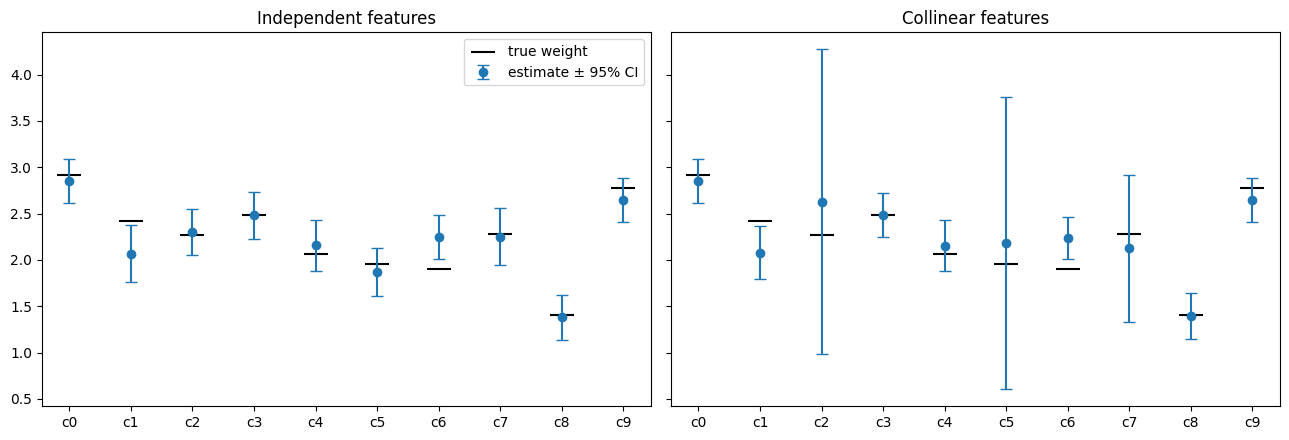

Variance inflation factors (collinear set):
c0     1.1
c1     1.2
c2    52.1
c3     1.1
c4     1.2
c5    44.5
c6     1.1
c7    97.1
c8     1.1
c9     1.2
dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, res, title in [(axes[0], res_ind, "Independent features"), (axes[1], res_col, "Collinear features")]:
    c = res.conf_int().loc[cols]
    ax.errorbar(range(10), res.params[cols], yerr=[res.params[cols] - c[0], c[1] - res.params[cols]],
                fmt="o", capsize=4, label="estimate ± 95% CI")
    ax.scatter(range(10), true_w, marker="_", s=300, color="k", label="true weight")
    ax.set_xticks(range(10)); ax.set_xticklabels(cols); ax.set_title(title)
axes[0].legend(); plt.tight_layout(); plt.show()

print("Variance inflation factors (collinear set):")
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xc = sm.add_constant(X_col)
print(pd.Series([variance_inflation_factor(Xc.values, i + 1) for i in range(10)], index=cols).round(1))

The collinear fit has about the same R² and predictive quality, but the confidence intervals for `c2`, `c5` and `c7` are several times wider, and the VIFs for those three are large while the rest sit near 1. The report warns of this as well (see the condition-number note at the bottom of the summary). The wide intervals are the statistical version of the instability seen across the 20 splits.

## 10. What is VIF?

The **variance inflation factor** measures how well a feature is explained by the *other features*.

For feature *j*:
1. Regress feature *j* on all the other features (not on y).
2. Take that regression's $R^2_j$.
3. $\text{VIF}_j = \dfrac{1}{1 - R^2_j}$

| $R^2_j$ | VIF |
|---|---|
| 0 | 1 (independent) |
| 0.9 | 10 |
| 0.99 | 100 |
| 1 | ∞ (exact collinearity) |

In OLS, $\text{Var}(\hat\beta_j) = \dfrac{\sigma^2}{(1 - R^2_j)\sum_i (x_{ij}-\bar x_j)^2}$, so VIF is exactly the factor by which collinearity inflates the coefficient's variance. Its standard error (and CI width) grows by $\sqrt{\text{VIF}}$. Rules of thumb: above ~5 deserves a look, above ~10 is a serious problem.

VIF also catches multi-column dependencies like `c7 ≈ 2*c2 - 1.5*c5`, where no single pairwise correlation is alarming. Below we compute it by hand and compare with statsmodels.

In [15]:
def vif_by_hand(X, j):
    others = X.drop(columns=j)
    r2 = LinearRegression().fit(others, X[j]).score(others, X[j])
    return 1 / (1 - r2)

by_hand = pd.Series({c: vif_by_hand(X_col, c) for c in cols})
from_sm = pd.Series([variance_inflation_factor(sm.add_constant(X_col).values, i + 1) for i in range(10)], index=cols)

pd.DataFrame({"by hand": by_hand, "statsmodels": from_sm}).round(2)

,by hand,statsmodels
c0,1.10,1.10
c1,1.18,1.18
c2,52.14,52.14
c3,1.09,1.09
c4,1.16,1.16
c5,44.47,44.47
c6,1.09,1.09
c7,97.12,97.12
c8,1.08,1.08
c9,1.18,1.18


In [16]:
print("max abs difference:", (by_hand - from_sm).abs().max())
print("sqrt(VIF) = SE inflation vs. independent fit:")
pd.DataFrame({"sqrt(VIF)": np.sqrt(by_hand),
              "actual SE ratio (col/ind)": res_col.bse[cols] / res_ind.bse[cols]}).round(2)

max abs difference: 2.220446049250313e-16
sqrt(VIF) = SE inflation vs. independent fit:


,sqrt(VIF),actual SE ratio (col/ind)
c0,1.05,1.00
c1,1.09,0.93
c2,7.22,6.57
c3,1.04,0.93
c4,1.07,1.00
c5,6.67,5.99
c6,1.05,0.98
c7,9.86,2.60
c8,1.04,1.01
c9,1.09,0.99
